## Pydeseq2 - matched lung data
## DEG's - iML in lung normal vs iML in lung tumor
## DEG's - iML in lung tumor vs cNK in lung tumor

In [1]:
# python version- 3.10.14

In [1]:
import scanpy as sc
import anndata
import pandas as pd
from matplotlib import rcParams
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.backends.backend_pdf import PdfPages
import seaborn as sns

In [2]:
adata=sc.read_h5ad("/Volumes/jennifer.a.foltz/Active/Veda/pan_cancer/profiling/updated_batch_pan_cancer_v4_dataset_v2_PtID_v2_extra_datasets_removal/pan_cancer_eMLclassified_adata_batch_dataset_v2_after_extra_datasets_removed_classification_allGenes.h5ad")

In [3]:
adata

AnnData object with n_obs × n_vars = 82408 × 14337
    obs: 'sample', 'batch', 'subset', 'dataset', 'source', 'total_counts', 'n_genes_by_counts', 'pct_counts_mt', '_scvi_batch', '_scvi_labels', 'tissue_residency_auc', 'HALLMARK_CHOLESTEROL_HOMEOSTASIS_auc', 'HALLMARK_TGF_BETA_SIGNALING_auc', 'HALLMARK_OXIDATIVE_PHOSPHORYLATION_auc', 'GOBP_RESPONSE_TO_PROSTAGLANDIN_auc', 'HALLMARK_HYPOXIA_auc', 'HALLMARK_REACTIVE_OXYGEN_SPECIES_PATHWAY_auc', 'HALLMARK_MTORC1_SIGNALING_auc', 'HALLMARK_NOTCH_SIGNALING_auc', 'KEGG_NATURAL_KILLER_CELL_MEDIATED_CYTOTOXICITY_auc', 'HALLMARK_GLYCOLYSIS_auc', 'HALLMARK_WNT_BETA_CATENIN_SIGNALING_auc', 'subset_source', 'bright_dim_subset', 'reference', 'Malmberg_patient', 'patient_ID', 'dataset_v2', 'patient_ID_v2', 'classification'
    uns: '_scvi_manager_uuid', '_scvi_uuid', 'bright_dim_subset_colors', 'neighbors', 'subset_colors', 'subset_source_colors', 'umap'
    obsm: 'X_scVI', 'X_umap'
    layers: 'norm'
    obsp: 'connectivities', 'distances'

In [4]:
adata.obs["classification"].value_counts()

classification
CD56dim          65194
ML1               5371
CD56bright        4839
ML_transition     2898
ML2               2617
unclassified      1489
Name: count, dtype: int64

In [5]:
adata.obs["source"].value_counts()

source
lung_normal        23433
PBMC               23120
lung_tumor         17860
glioblastoma        5305
breast_tumor        4941
melanoma            2714
sarcoma             1621
pancreas_tumor      1104
pancreas_normal      655
breast_normal        603
prostate_tumor       530
prostate_normal      265
skin_normal          257
Name: count, dtype: int64

In [6]:
#filtering adata by patients with multiple sources and focus on lung

In [7]:
# Count unique sources per patient
patient_source_counts = adata.obs.groupby("patient_ID_v2")["source"].nunique()

# Identify patients with >1 unique source
patients_multiple_sources = patient_source_counts[patient_source_counts > 1].index

# Filter adata to only include those patients
adata_filtered = adata[adata.obs["patient_ID_v2"].isin(patients_multiple_sources)].copy()

/var/folders/kd/m1qdx0dj5yj9ccknd3w46p9m0000gr/T/ipykernel_89661/1508113905.py:2: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  patient_source_counts = adata.obs.groupby("patient_ID_v2")["source"].nunique()


In [8]:
adata_filtered.obs["patient_ID_v2"].nunique()

77

In [9]:
adata_filtered = adata_filtered[adata_filtered.obs["source"].isin(["lung_normal", "lung_tumor"])].copy()

In [10]:
adata_filtered

AnnData object with n_obs × n_vars = 31932 × 14337
    obs: 'sample', 'batch', 'subset', 'dataset', 'source', 'total_counts', 'n_genes_by_counts', 'pct_counts_mt', '_scvi_batch', '_scvi_labels', 'tissue_residency_auc', 'HALLMARK_CHOLESTEROL_HOMEOSTASIS_auc', 'HALLMARK_TGF_BETA_SIGNALING_auc', 'HALLMARK_OXIDATIVE_PHOSPHORYLATION_auc', 'GOBP_RESPONSE_TO_PROSTAGLANDIN_auc', 'HALLMARK_HYPOXIA_auc', 'HALLMARK_REACTIVE_OXYGEN_SPECIES_PATHWAY_auc', 'HALLMARK_MTORC1_SIGNALING_auc', 'HALLMARK_NOTCH_SIGNALING_auc', 'KEGG_NATURAL_KILLER_CELL_MEDIATED_CYTOTOXICITY_auc', 'HALLMARK_GLYCOLYSIS_auc', 'HALLMARK_WNT_BETA_CATENIN_SIGNALING_auc', 'subset_source', 'bright_dim_subset', 'reference', 'Malmberg_patient', 'patient_ID', 'dataset_v2', 'patient_ID_v2', 'classification'
    uns: '_scvi_manager_uuid', '_scvi_uuid', 'bright_dim_subset_colors', 'neighbors', 'subset_colors', 'subset_source_colors', 'umap'
    obsm: 'X_scVI', 'X_umap'
    layers: 'norm'
    obsp: 'connectivities', 'distances'

In [11]:
adata_filtered.obs["patient_ID_v2"].nunique()

61

In [12]:
unique_counts = adata_filtered.obs.groupby('dataset_v2')['patient_ID_v2'].nunique()
print(unique_counts)

dataset_v2
bischoff        8
chan            2
kim            10
lambrechts      7
leader         22
leader_cite     8
he_D            5
Name: patient_ID_v2, dtype: int64


/var/folders/kd/m1qdx0dj5yj9ccknd3w46p9m0000gr/T/ipykernel_89661/3163753349.py:1: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  unique_counts = adata_filtered.obs.groupby('dataset_v2')['patient_ID_v2'].nunique()


In [13]:
adata_filtered.obs["source"].unique()

['lung_normal', 'lung_tumor']
Categories (2, object): ['lung_normal', 'lung_tumor']

In [14]:
adata_filtered.obs["classification"].value_counts()

classification
CD56dim          27181
ML1               1477
CD56bright        1076
ML2               1015
ML_transition      836
unclassified       347
Name: count, dtype: int64

In [145]:
adata_filtered = adata_filtered[adata_filtered.obs['classification'] != 'unclassified'].copy()
adata_filtered.obs['classification'] = adata_filtered.obs['classification'].replace({
    'CD56bright': 'cNK',
    'CD56dim': 'cNK',
    'ML1': 'eML',
    'ML2': 'eML',
    'ML_transition': 'eML'
})
adata_filtered.obs['classification'] = adata_filtered.obs['classification'].astype('category')

In [146]:
adata_filtered.obs["classification"].value_counts()

classification
cNK    28257
eML     3328
Name: count, dtype: int64

In [147]:
# Create a new column 'combined' by joining 'classification' and 'source'
adata_filtered.obs['classification_source'] = adata_filtered.obs['classification'].astype(str) + "_" + adata_filtered.obs['source'].astype(str)

In [148]:
adata_filtered.obs["classification_source"].value_counts()

classification_source
cNK_lung_normal    18811
cNK_lung_tumor      9446
eML_lung_tumor      1902
eML_lung_normal     1426
Name: count, dtype: int64

In [149]:
adata_filtered

AnnData object with n_obs × n_vars = 31585 × 14337
    obs: 'sample', 'batch', 'subset', 'dataset', 'source', 'total_counts', 'n_genes_by_counts', 'pct_counts_mt', '_scvi_batch', '_scvi_labels', 'tissue_residency_auc', 'HALLMARK_CHOLESTEROL_HOMEOSTASIS_auc', 'HALLMARK_TGF_BETA_SIGNALING_auc', 'HALLMARK_OXIDATIVE_PHOSPHORYLATION_auc', 'GOBP_RESPONSE_TO_PROSTAGLANDIN_auc', 'HALLMARK_HYPOXIA_auc', 'HALLMARK_REACTIVE_OXYGEN_SPECIES_PATHWAY_auc', 'HALLMARK_MTORC1_SIGNALING_auc', 'HALLMARK_NOTCH_SIGNALING_auc', 'KEGG_NATURAL_KILLER_CELL_MEDIATED_CYTOTOXICITY_auc', 'HALLMARK_GLYCOLYSIS_auc', 'HALLMARK_WNT_BETA_CATENIN_SIGNALING_auc', 'subset_source', 'bright_dim_subset', 'reference', 'Malmberg_patient', 'patient_ID', 'dataset_v2', 'patient_ID_v2', 'classification', 'classification_source'
    uns: '_scvi_manager_uuid', '_scvi_uuid', 'bright_dim_subset_colors', 'neighbors', 'subset_colors', 'subset_source_colors', 'umap'
    obsm: 'X_scVI', 'X_umap'
    layers: 'norm'
    obsp: 'connectivities

# PYDESEQ2

In [150]:
import warnings
import decoupler as dc
import pertpy as pt
import scanpy as sc
warnings.filterwarnings("ignore")

In [151]:
adata_filtered.layers["counts"] = adata_filtered.X.copy()

In [152]:
#pseudobulk

In [153]:
pdata = dc.pp.pseudobulk(adata_filtered, sample_col="patient_ID_v2", groups_col="classification_source", layer="counts", mode="sum")

In [154]:
dc.pp.filter_samples(pdata, inplace=True)
pdata

AnnData object with n_obs × n_vars = 190 × 14337
    obs: 'patient_ID_v2', 'classification_source', 'source', '_scvi_labels', 'reference', 'patient_ID', 'classification', 'psbulk_cells', 'psbulk_counts'
    layers: 'psbulk_props'

In [155]:
adata_filtered.obs["patient_ID_v2"].nunique()

61

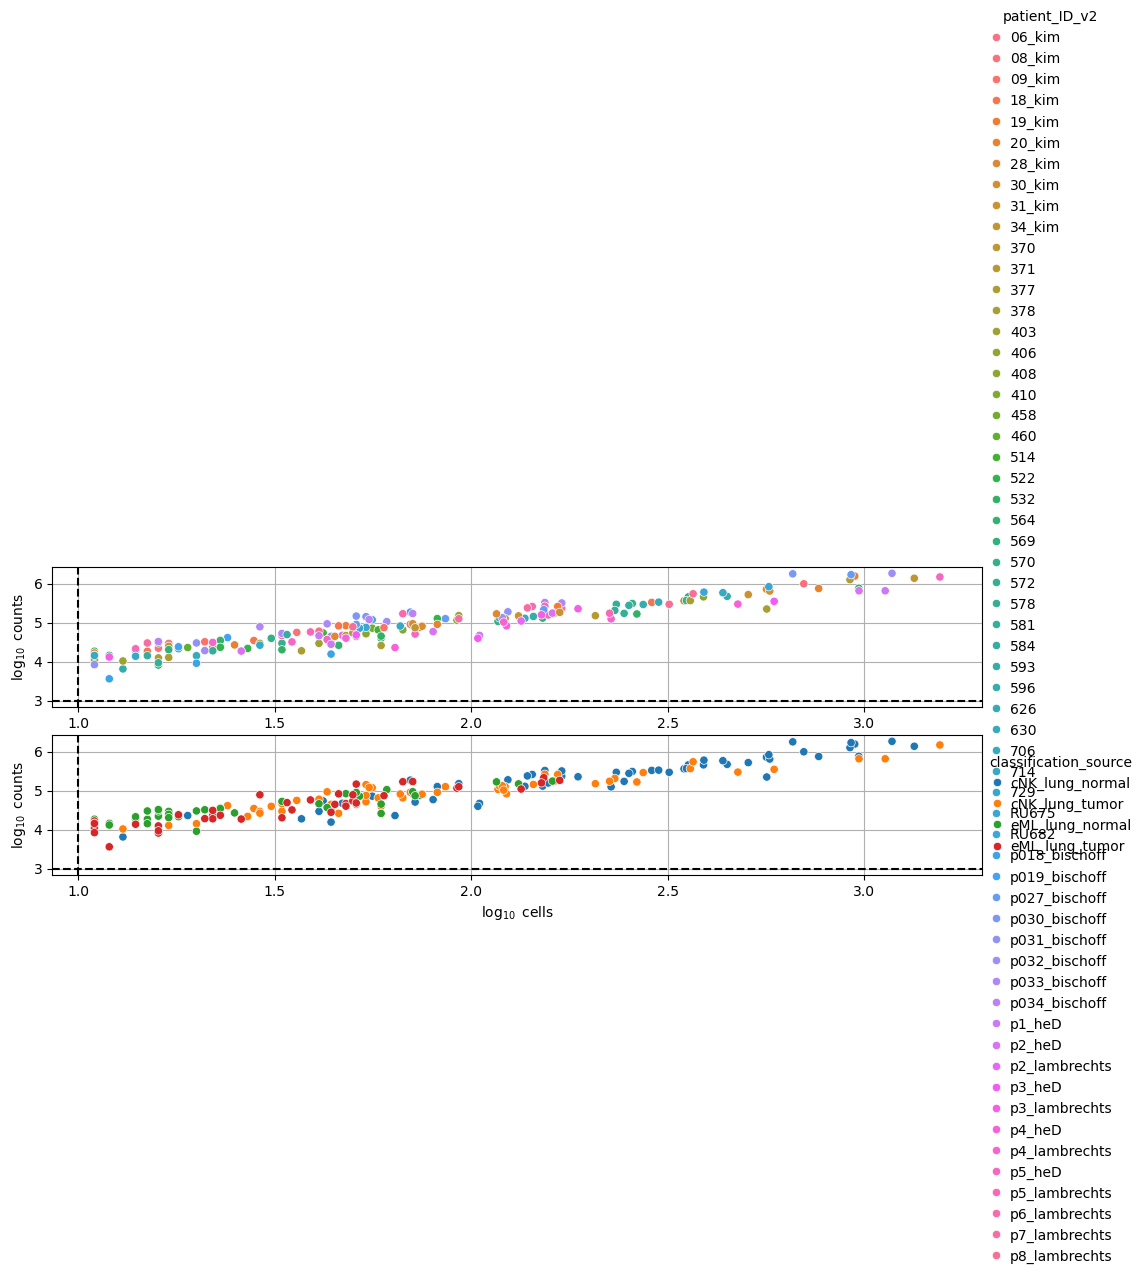

In [156]:
dc.pl.filter_samples(pdata, groupby=["patient_ID_v2", "classification_source"], figsize=(12, 4))

In [157]:
pdata.layers["counts"] = pdata.X.copy()

sc.pp.normalize_total(pdata, target_sum=1e4)
sc.pp.log1p(pdata)
sc.pp.scale(pdata, max_value=10)
sc.pp.pca(pdata)

In [158]:
pdata

AnnData object with n_obs × n_vars = 190 × 14337
    obs: 'patient_ID_v2', 'classification_source', 'source', '_scvi_labels', 'reference', 'patient_ID', 'classification', 'psbulk_cells', 'psbulk_counts'
    var: 'mean', 'std'
    uns: 'log1p', 'pca'
    obsm: 'X_pca'
    varm: 'PCs'
    layers: 'psbulk_props', 'counts'

In [159]:
# Return raw counts to X
dc.pp.swap_layer(pdata, "counts", inplace=True)

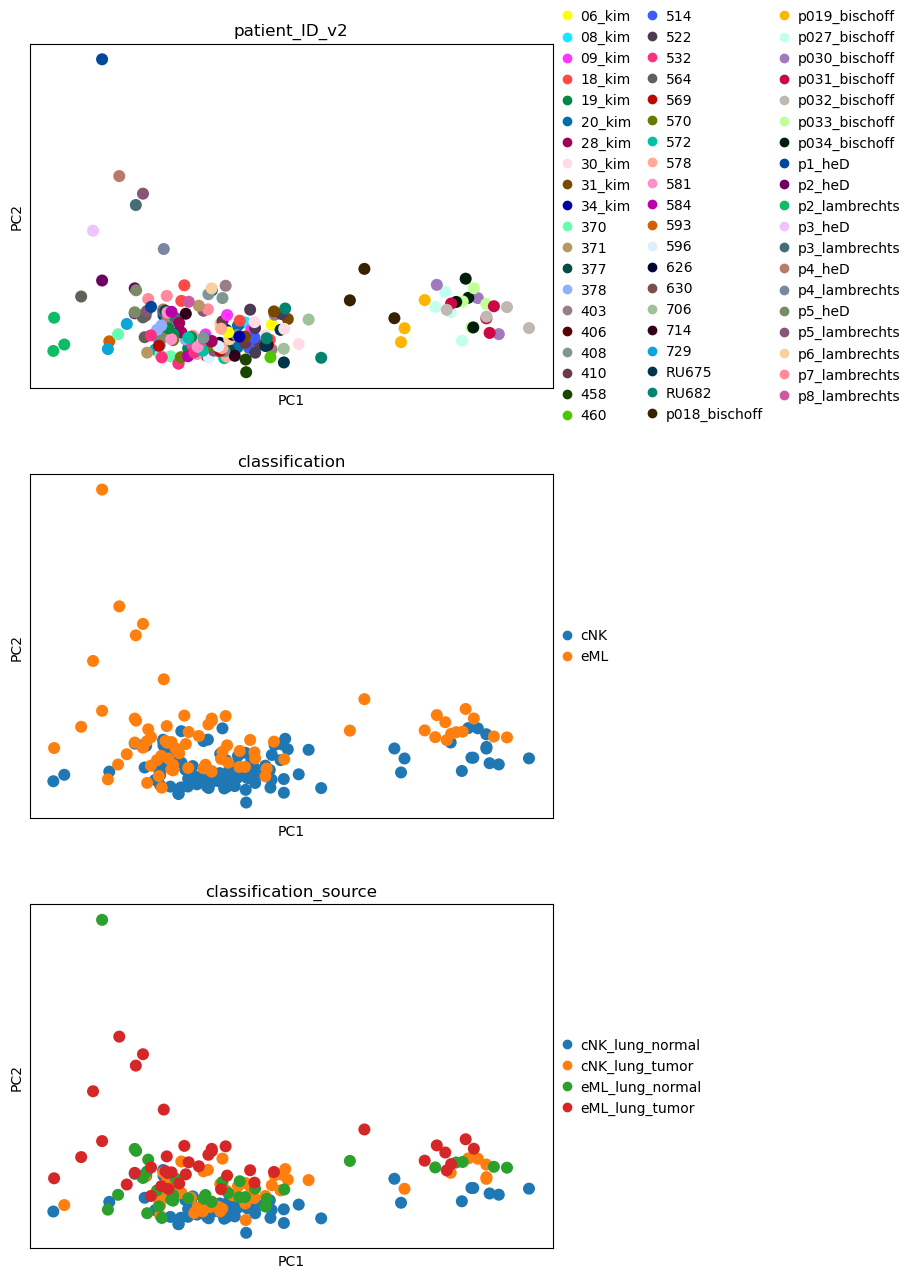

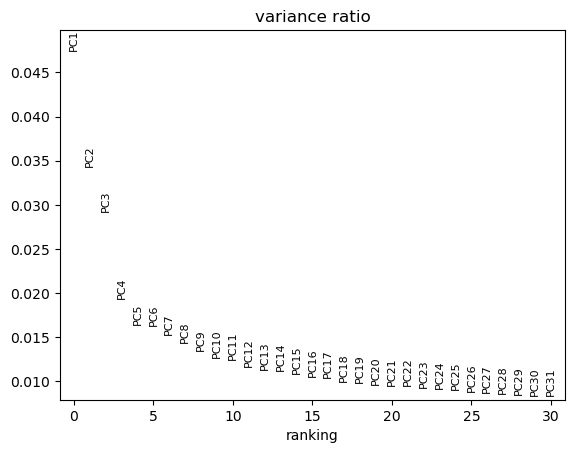

In [160]:
sc.pl.pca(pdata, color=["patient_ID_v2", "classification", "classification_source"], ncols=1, size=300)
sc.pl.pca_variance_ratio(pdata)

In [161]:
pdata_subset = pdata.copy()
pdata_subset.obs = pdata.obs[["patient_ID_v2",  "classification_source"]]

dc.tl.rankby_obsm(
    pdata_subset,
    key="X_pca",
    uns_key="pca_anova",
)

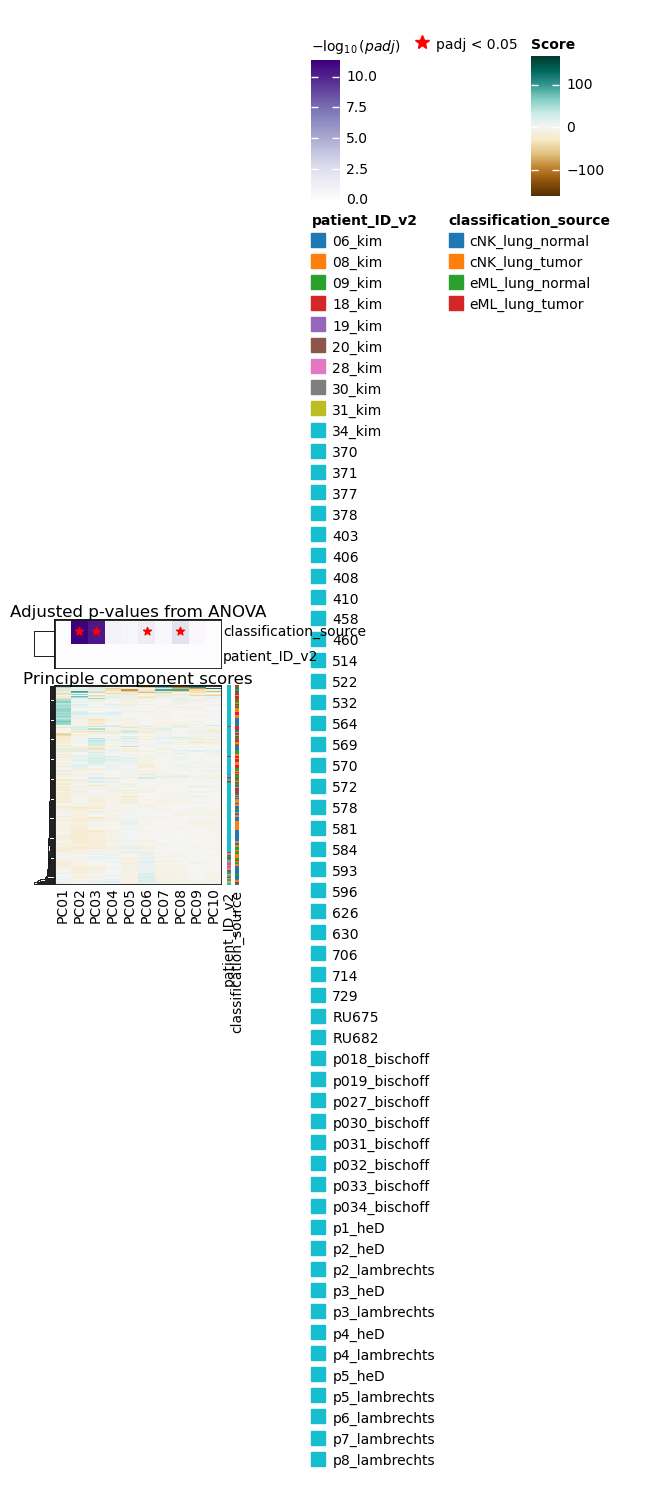

In [162]:
dc.pl.obsm(
    pdata_subset,
    key="pca_anova",
    names=["patient_ID_v2",  "classification_source"],
    titles=["Principle component scores", "Adjusted p-values from ANOVA"],
    cmap_obs={},
)

In [163]:
pdata_subset.obs['patient_ID_v2'] = pdata_subset.obs['patient_ID_v2'].astype('category')

## iML_lung_tumor vs iML_lung_normal

In [166]:
pds2 = pt.tl.PyDESeq2(adata=pdata, design="~ patient_ID_v2 + classification_source")

In [167]:
pds2.fit()

Fitting size factors...
... done in 0.03 seconds.



Using None as control genes, passed at DeseqDataSet initialization


Fitting dispersions...
... done in 2.96 seconds.

Fitting dispersion trend curve...
... done in 0.15 seconds.

Fitting MAP dispersions...
... done in 5.33 seconds.

Fitting LFCs...
... done in 6.47 seconds.

Calculating cook's distance...
... done in 0.10 seconds.

Replacing 0 outlier genes.



In [168]:
res_df = pds2.test_contrasts(pds2.contrast(column="classification_source", baseline="eML_lung_normal", group_to_compare="eML_lung_tumor"))

Running Wald tests...


Log2 fold change & Wald test p-value, contrast vector: [ 0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.
  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.
  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.
  0.  0.  0.  0.  0.  0. -1.  1.]
            baseMean  log2FoldChange     lfcSE      stat    pvalue      padj
CAPRIN2     1.525586       -0.127316  0.369851 -0.344237  0.730668  0.944424
VIM        81.892763        0.374013  0.140168  2.668312  0.007623  0.098980
TRUB2       2.354887       -0.057359  0.279486 -0.205229  0.837393  0.965617
MED12L      0.007567       -0.123837  4.860268 -0.025479  0.979673       NaN
BTN3A3      4.415648       -0.117428  0.258650 -0.454004  0.649826  0.925527
...              ...             ...       ...       ...       ...       ...
PRELID1    37.168043        0.020559  0.081155  0.253323  0.800019  0.960281
NPR3        0.005030       -0.131470  4.860865 -0.027047  0.978423       NaN

... done in 0.53 seconds.



In [169]:
res_df.head(10)

,variable,baseMean,log_fc,lfcSE,stat,p_value,adj_p_value,contrast
0,ARL6IP4,18.412110,-6.540814,0.445774,-14.672935,9.609743e-49,7.685872e-45,None
1,SPON2,92.771409,-1.811296,0.220516,-8.213882,2.141508e-16,8.563889e-13,None
2,PLAC8,76.424391,-1.499116,0.184698,-8.116600,4.794272e-16,1.278153e-12,None
3,RGS1,76.785350,1.576360,0.205453,7.672589,1.685583e-14,3.212319e-11,None
4,S1PR5,23.986679,-1.835271,0.239902,-7.650102,2.008201e-14,3.212319e-11,None
5,EMP3,67.545278,-0.802914,0.110149,-7.289332,3.114959e-13,4.152240e-10,None
6,TUBA1B,45.527194,-1.067821,0.149780,-7.129250,1.009176e-12,1.134428e-09,None
7,FGFBP2,129.756664,-1.929643,0.271280,-7.113092,1.134712e-12,1.134428e-09,None
8,KIR3DL2,3.354892,-3.434131,0.488501,-7.029939,2.066234e-12,1.836193e-09,None
9,PXN,8.183936,-2.028817,0.292204,-6.943162,3.834206e-12,3.066598e-09,None


In [170]:
filtered_res_df = res_df[res_df['adj_p_value'] < 0.05]
print(filtered_res_df)

    variable   baseMean    log_fc     lfcSE       stat       p_value  \
0    ARL6IP4  18.412110 -6.540814  0.445774 -14.672935  9.609743e-49   
1      SPON2  92.771409 -1.811296  0.220516  -8.213882  2.141508e-16   
2      PLAC8  76.424391 -1.499116  0.184698  -8.116600  4.794272e-16   
3       RGS1  76.785350  1.576360  0.205453   7.672589  1.685583e-14   
4      S1PR5  23.986679 -1.835271  0.239902  -7.650102  2.008201e-14   
..       ...        ...       ...       ...        ...           ...   
450    WDR45   8.033344 -0.488948  0.163312  -2.993952  2.753896e-03   
451    MICU2   6.318324 -0.570424  0.190570  -2.993250  2.760240e-03   
452   RNF166  16.225464 -0.397813  0.133133  -2.988082  2.807346e-03   
453  UBASH3B   1.592845  1.154467  0.386663   2.985721  2.829105e-03   
454   PPP1CB  18.839826  0.365049  0.122289   2.985121  2.834659e-03   

      adj_p_value contrast  
0    7.685872e-45     None  
1    8.563889e-13     None  
2    1.278153e-12     None  
3    3.212319e-11  

In [171]:
#filtered_res_df.to_csv('/Volumes/jennifer.a.foltz/Active/Veda/pan_cancer/adata_combined_malm_ding_Tcell_filtered_fan_included/output/Pydeseq2_lung_match_eMLTvseMLN_adj_pvalue_<0.05.csv', index= False)

In [172]:
adata_filtered_2 = adata_filtered.copy()

# Ensure raw counts or normalized expression are accessible
expr_matrix = adata_filtered_2.X  # or adata.layers["counts"], depending on what you used

# Get boolean mask for each group
eML_lung_normal_mask = adata_filtered_2.obs["classification_source"] == "eML_lung_normal"
eML_lung_tumor_mask = adata_filtered_2.obs["classification_source"] == "eML_lung_tumor"

# Convert to array if sparse
if not isinstance(expr_matrix, np.ndarray):
    expr_matrix = expr_matrix.toarray()

# Calculate % of cells expressing each gene in each group
eML_lung_normal_expr_percent = np.sum(expr_matrix[eML_lung_normal_mask, :] > 0, axis=0) / np.sum(eML_lung_normal_mask) * 100
eML_lung_tumor_expr_percent = np.sum(expr_matrix[eML_lung_tumor_mask, :] > 0, axis=0) / np.sum(eML_lung_tumor_mask) * 100

# Put results into a DataFrame
percent_expr_df = pd.DataFrame({
    "gene": adata_filtered_2.var_names,
    "iML_lung_normal_percent": eML_lung_normal_expr_percent,
    "iML_lung_tumor_percent": eML_lung_tumor_expr_percent
})

# Merge on gene name (make sure the DE result column name matches)
merged_res = filtered_res_df.merge(
    percent_expr_df, 
    left_on="variable",   
    right_on="gene",
    how="left"
)
merged_res = merged_res.drop_duplicates(subset="gene").reset_index(drop=True)

In [173]:
merged_res

,variable,baseMean,log_fc,lfcSE,stat,p_value,adj_p_value,contrast,gene,iML_lung_normal_percent,iML_lung_tumor_percent
0,ARL6IP4,18.412110,-6.540814,0.445774,-14.672935,9.609743e-49,7.685872e-45,None,ARL6IP4,42.075736,0.000000
1,SPON2,92.771409,-1.811296,0.220516,-8.213882,2.141508e-16,8.563889e-13,None,SPON2,39.060309,12.776025
2,PLAC8,76.424391,-1.499116,0.184698,-8.116600,4.794272e-16,1.278153e-12,None,PLAC8,44.389902,15.667718
3,RGS1,76.785350,1.576360,0.205453,7.672589,1.685583e-14,3.212319e-11,None,RGS1,34.291725,53.470032
4,S1PR5,23.986679,-1.835271,0.239902,-7.650102,2.008201e-14,3.212319e-11,None,S1PR5,26.016830,5.835962
...,...,...,...,...,...,...,...,...,...,...,...
449,WDR45,8.033344,-0.488948,0.163312,-2.993952,2.753896e-03,4.894591e-02,None,WDR45,12.833100,9.358570
450,MICU2,6.318324,-0.570424,0.190570,-2.993250,2.760240e-03,4.894988e-02,None,MICU2,11.079944,8.412198
451,RNF166,16.225464,-0.397813,0.133133,-2.988082,2.807346e-03,4.967512e-02,None,RNF166,22.791024,17.402734
452,UBASH3B,1.592845,1.154467,0.386663,2.985721,2.829105e-03,4.993744e-02,None,UBASH3B,2.033661,4.258675


In [174]:
#merged_res.to_csv('/Volumes/jennifer.a.foltz/Active/Veda/pan_cancer/adata_combined_malm_ding_Tcell_filtered_fan_included/output/Pydeseq2_lung_match_eMLTvseMLN_adj_pvalue_<0.05_cells_percent_added.csv', index= False)

NaNs encountered, dropping rows with NaNs


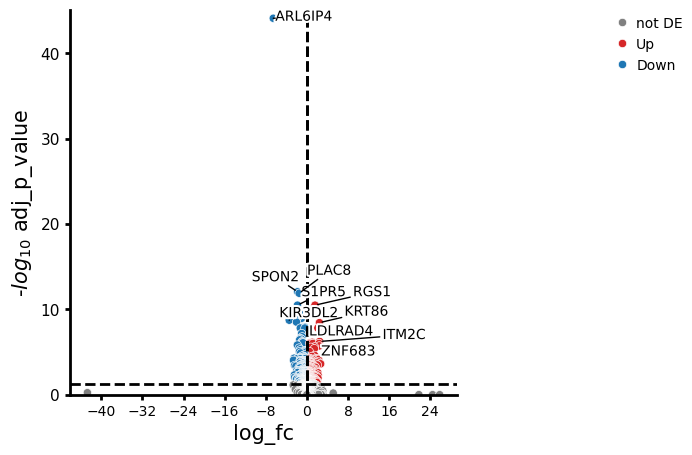

In [175]:
pds2.plot_volcano(res_df, log2fc_thresh=0)

In [176]:
import matplotlib.patheffects as path_effects
from adjustText import adjust_text

In [177]:
filtered_res_df= res_df

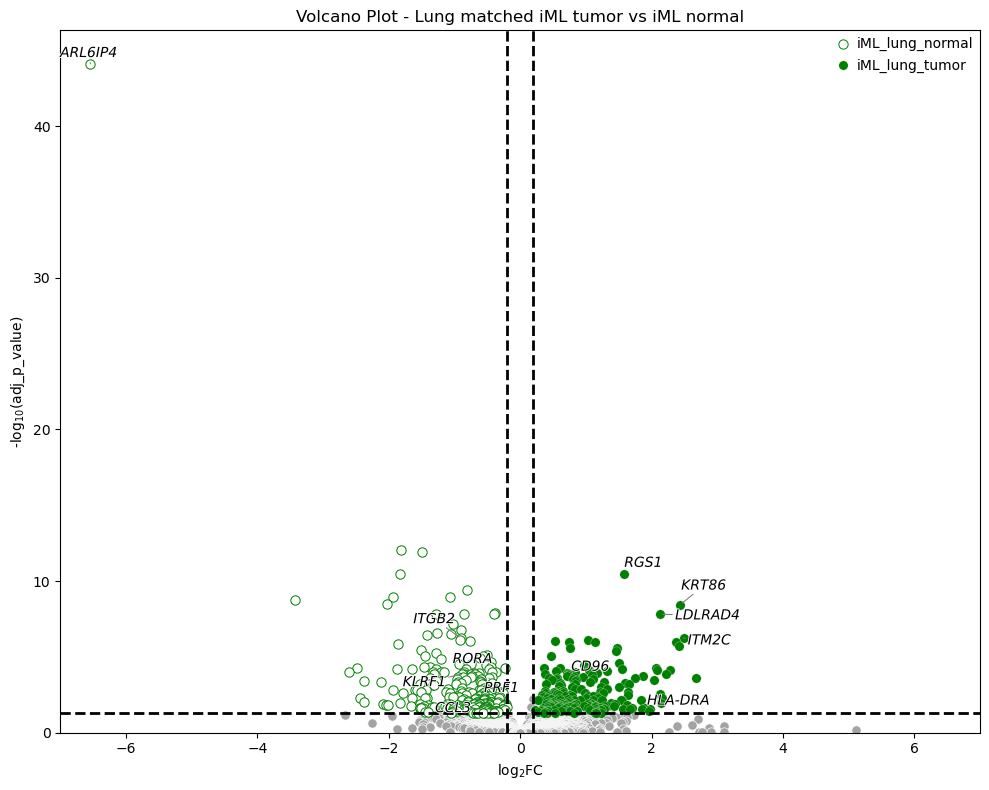

In [184]:
filtered_res_df = filtered_res_df[(filtered_res_df["log_fc"] > -12) & (filtered_res_df["log_fc"] < 8)]

# Ensure gene names are in index
filtered_res_df = filtered_res_df.set_index("variable", drop=False)
filtered_res_df["-log10(adj_p_value)"] = -np.log10(filtered_res_df["adj_p_value"])

plt.figure(figsize=(10,8))

# Significance thresholds
pval_threshold = 0.05
logfc_threshold = 0.2

# Plot all genes in light gray
plt.scatter(
    filtered_res_df["log_fc"], 
    filtered_res_df["-log10(adj_p_value)"], 
    color="#a3a3a3", s=45, label="_nolegend_",
    edgecolors="white", linewidth=0.5
)

#  Identify significant up/down genes
sig_up = filtered_res_df[(filtered_res_df["log_fc"] > logfc_threshold) & 
                         (filtered_res_df["adj_p_value"] < pval_threshold)]
sig_down = filtered_res_df[(filtered_res_df["log_fc"] < -logfc_threshold) & 
                           (filtered_res_df["adj_p_value"] < pval_threshold)]

# Overlay significant genes
plt.scatter(
    sig_down["log_fc"], 
    sig_down["-log10(adj_p_value)"], 
    facecolors="white",        # White fill
    edgecolors="green",        # White outline
    linewidth=0.70,             # Adjust outline thickness
    s=45, 
    label="iML_lung_normal"
)

plt.scatter(
    sig_up["log_fc"], 
    sig_up["-log10(adj_p_value)"], 
    facecolors="green",        # Green fill
    edgecolors="white",        # White outline
    linewidth=0.18,             # Adjust outline thickness
    s=45, 
    label="iML_lung_tumor"
)


# Label genes of interest
genes_to_label = ["HLA-DRA", "RGS1", "KRT86", "LDLRAD4",
    "ITM2C", "CD96",  "ARL6IP4", "PRF1",
    "CCL3", "RORA", "KLRF1", "ITGB2"]

texts = []
for gene in genes_to_label:
    if gene in filtered_res_df.index:
        x = filtered_res_df.loc[gene, "log_fc"]
        y = filtered_res_df.loc[gene, "-log10(adj_p_value)"]
        text = plt.text(
            x, y, gene, fontsize=10, color="black",
            ha='left' if x > 0 else 'right', fontstyle='italic',
        )
        # ➕ Add white outline around text
        text.set_path_effects([
            path_effects.Stroke(linewidth=1.2, foreground='white'),
            path_effects.Normal()
        ])
        texts.append(text)


# Adjust label positions
adjust_text(
    texts,
    arrowprops=dict(arrowstyle="-", color="gray", lw=0.8),
    only_move={'points':'y', 'texts':'xy'},
    force_text=0.8
)

# Reference line + labels
#plt.axvline(0, color="black", linestyle="--", lw=2.2)
plt.axhline(-np.log10(pval_threshold), color="black", linestyle="--",  lw=2)
plt.axvline(logfc_threshold, color="black", linestyle="--", lw=2)
plt.axvline(-logfc_threshold, color="black", linestyle="--", lw=2)
plt.ylim(bottom=0)
xmax = max(abs(filtered_res_df["log_fc"].min()), abs(filtered_res_df["log_fc"].max()))
plt.xlim(-7,7)
plt.xlabel("log$_2$FC")
plt.ylabel(r"-log$_{10}$(adj_p_value)")

plt.title("Volcano Plot - Lung matched iML tumor vs iML normal")
plt.legend(frameon=False)
plt.tight_layout()
plt.show()


In [179]:
#!pip install brokenaxes

In [180]:
from brokenaxes import brokenaxes

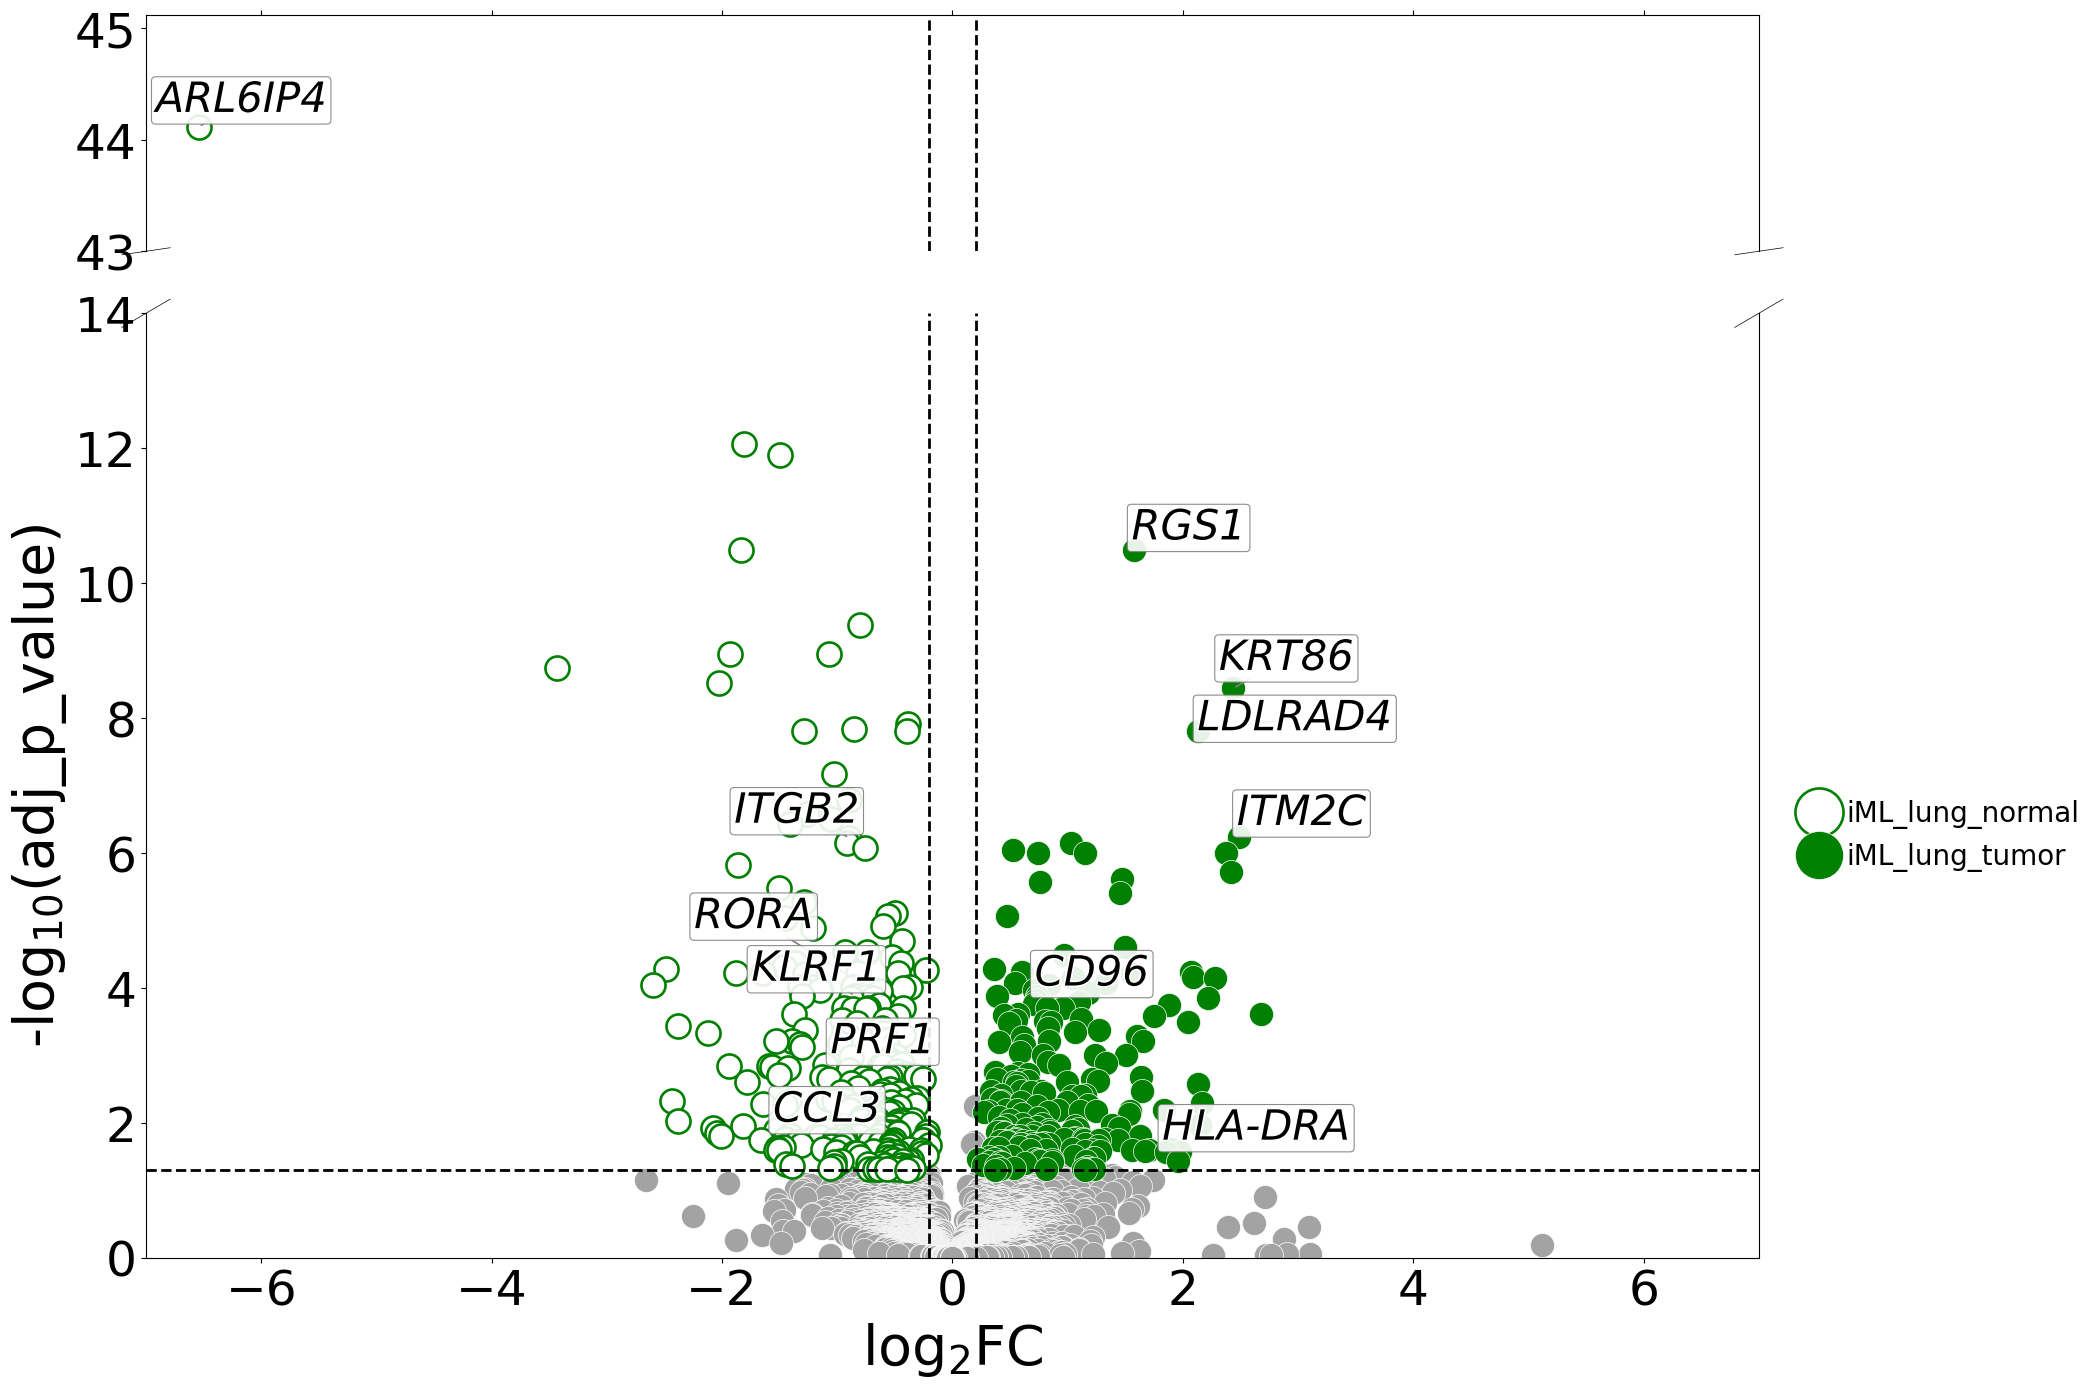

In [185]:
# Create figure with two subplots sharing x-axis
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(21, 14), 
                                sharex=True, gridspec_kw={'height_ratios': [1, 4]})
fig.subplots_adjust(hspace=0.05)

# Significance thresholds
pval_threshold = 0.05
logfc_threshold = 0.2

# Plot on both axes
for ax in [ax1, ax2]:
    # All genes in light gray
    ax.scatter(filtered_res_df["log_fc"], filtered_res_df["-log10(adj_p_value)"], 
               color="#a3a3a3", s=300, edgecolors="white", linewidth=0.5)
    
    # Significant down-regulated
    ax.scatter(sig_down["log_fc"], sig_down["-log10(adj_p_value)"], 
               facecolors="white", edgecolors="green", linewidth=1.90, s=300,
               label="iML_lung_normal" if ax == ax2 else "_nolegend_")
    
    # Significant up-regulated
    ax.scatter(sig_up["log_fc"], sig_up["-log10(adj_p_value)"], 
               facecolors="green", edgecolors="white", linewidth=0.5, s=300,
               label="iML_lung_tumor" if ax == ax2 else "_nolegend_")
    
    # Reference lines
    ax.axhline(-np.log10(pval_threshold), color="black", linestyle="--", lw=2)
    ax.axvline(logfc_threshold, color="black", linestyle="--", lw=2)
    ax.axvline(-logfc_threshold, color="black", linestyle="--", lw=2)

# Set different y-limits
ax1.set_ylim(43, filtered_res_df["-log10(adj_p_value)"].max() +1)  # Top plot - outlier
ax2.set_ylim(0, 14)   # Bottom plot - main data

# Hide spines between plots
ax1.spines['bottom'].set_visible(False)
ax2.spines['top'].set_visible(False)
ax1.xaxis.tick_top()
ax1.tick_params(labeltop=False)
ax2.xaxis.tick_bottom()

# Add diagonal lines to indicate axis break
d = 0.015
kwargs = dict(transform=ax1.transAxes, color='k', clip_on=False, linewidth=0.5)
ax1.plot((-d, +d), (-d, +d), **kwargs)
ax1.plot((1 - d, 1 + d), (-d, +d), **kwargs)

kwargs.update(transform=ax2.transAxes)
ax2.plot((-d, +d), (1 - d, 1 + d), **kwargs)
ax2.plot((1 - d, 1 + d), (1 - d, 1 + d), **kwargs)

# Label genes of interest
texts_ax1 = []
texts_ax2 = []

for gene in genes_to_label:
    if gene in filtered_res_df.index:
        x = filtered_res_df.loc[gene, "log_fc"]
        y = filtered_res_df.loc[gene, "-log10(adj_p_value)"]
        
        # Determine which axis to use based on y-value
        if y > 43:
            ax_use = ax1
            texts_list = texts_ax1
        else:
            ax_use = ax2
            texts_list = texts_ax2
        
        text = ax_use.text(
            x, y, gene, fontsize=30, color="black",
            ha='left' if x > 0 else 'right', fontstyle='italic',
                bbox=dict(
        boxstyle='round,pad=0.1',
        facecolor='white',
        edgecolor='gray',
        linewidth=0.8,
        alpha=0.9
    )
        )
        # Add white outline around text
        text.set_path_effects([
            path_effects.Stroke(linewidth=2.5, foreground='white'),
            path_effects.Normal()
        ])
        texts_list.append(text)

# Adjust text positions for each subplot
if texts_ax1:
    adjust_text(
        texts_ax1, ax=ax1,
        arrowprops=dict(arrowstyle="-", color="gray", lw=1.2),
        only_move={'points':'y', 'texts':'xy'},
        force_text=3.0
    )

if texts_ax2:
    adjust_text(
        texts_ax2, ax=ax2,
        arrowprops=dict(arrowstyle="-", color="gray", lw=1.2),
        only_move={'points':'y', 'texts':'xy'},
        force_text=3.0
    )

# Labels and legend
ax2.set_xlabel("log$_2$FC", fontsize=40)
plt.ylabel(r"-log$_{10}$(adj_p_value)",  fontsize=40)
ax2.legend(
    frameon=False,
    markerscale=2.0,
    loc='upper left',
    bbox_to_anchor=(1.02, 0.5),
    fontsize=20
)
plt.xlim(-7,7)
ax1.tick_params(axis='both', labelsize=35)  # Adjust size as needed
ax2.tick_params(axis='both', labelsize= 35)
plt.tight_layout()
plt.show()

## iML in tumor vs cNK in tumor

In [186]:
pds2 = pt.tl.PyDESeq2(adata=pdata, design="~ patient_ID_v2 + classification_source")
pds2.fit()

Fitting size factors...
... done in 0.04 seconds.



Using None as control genes, passed at DeseqDataSet initialization


Fitting dispersions...
... done in 3.37 seconds.

Fitting dispersion trend curve...
... done in 0.17 seconds.

Fitting MAP dispersions...
... done in 6.54 seconds.

Fitting LFCs...
... done in 7.44 seconds.

Calculating cook's distance...
... done in 0.12 seconds.

Replacing 0 outlier genes.



In [187]:
res_df = pds2.test_contrasts(pds2.contrast(column="classification_source", baseline="cNK_lung_tumor", group_to_compare="eML_lung_tumor"))

Running Wald tests...


Log2 fold change & Wald test p-value, contrast vector: [ 0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.
  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.
  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.
  0.  0.  0.  0.  0. -1.  0.  1.]
            baseMean  log2FoldChange     lfcSE      stat        pvalue  \
CAPRIN2     1.525586        0.178793  0.297935  0.600109  5.484339e-01   
VIM        81.892763        0.620122  0.123450  5.023261  5.080149e-07   
TRUB2       2.354887        0.399202  0.223969  1.782394  7.468494e-02   
MED12L      0.007567        1.168557  4.354352  0.268365  7.884182e-01   
BTN3A3      4.415648       -0.512965  0.205093 -2.501139  1.237947e-02   
...              ...             ...       ...       ...           ...   
PRELID1    37.168043        0.224153  0.065511  3.421607  6.225231e-04   
NPR3        0.005030        1.147739  4.355712  0.263502  7.921637e-01   
WDR5        1.159613      

... done in 0.68 seconds.



In [188]:
res_df.head(10)

,variable,baseMean,log_fc,lfcSE,stat,p_value,adj_p_value,contrast
0,FGFBP2,129.756664,-3.630672,0.241607,-15.027200,4.871653e-51,4.553047e-47,None
1,PLAC8,76.424391,-2.197011,0.163452,-13.441328,3.461667e-41,1.617637e-37,None
2,SPON2,92.771409,-2.452080,0.196343,-12.488755,8.598838e-36,2.678825e-32,None
3,PTGDS,57.483220,-4.391628,0.404530,-10.856129,1.864877e-27,3.776972e-24,None
4,CX3CR1,14.596604,-3.049801,0.281119,-10.848799,2.020636e-27,3.776972e-24,None
5,GZMK,44.033740,2.324800,0.214769,10.824662,2.630466e-27,4.097389e-24,None
6,GSTP1,75.055567,0.719431,0.066729,10.781303,4.218693e-27,5.632557e-24,None
7,BIN2,47.659550,-0.914122,0.085096,-10.742259,6.444784e-27,7.529119e-24,None
8,S1PR5,23.986679,-2.209579,0.213437,-10.352348,4.083468e-25,4.240455e-22,None
9,PRF1,190.608832,-0.919381,0.089781,-10.240244,1.309060e-24,1.223448e-21,None


In [189]:
filtered_res_df = res_df[res_df['adj_p_value'] < 0.05]
print(filtered_res_df)

     variable    baseMean    log_fc     lfcSE       stat       p_value  \
0      FGFBP2  129.756664 -3.630672  0.241607 -15.027200  4.871653e-51   
1       PLAC8   76.424391 -2.197011  0.163452 -13.441328  3.461667e-41   
2       SPON2   92.771409 -2.452080  0.196343 -12.488755  8.598838e-36   
3       PTGDS   57.483220 -4.391628  0.404530 -10.856129  1.864877e-27   
4      CX3CR1   14.596604 -3.049801  0.281119 -10.848799  2.020636e-27   
...       ...         ...       ...       ...        ...           ...   
1257     DTNB    1.217645  0.853723  0.314631   2.713411  6.659451e-03   
1258  SUPT4H1   16.741047 -0.291243  0.107335  -2.713393  6.659809e-03   
1259   SCARB2    1.653920  0.764084  0.281680   2.712599  6.675779e-03   
1260   LRRC58    2.832576 -0.624033  0.230203  -2.710792  6.712280e-03   
1261   TCEAL4    2.917323  0.826716  0.305158   2.709139  6.745802e-03   

       adj_p_value contrast  
0     4.553047e-47     None  
1     1.617637e-37     None  
2     2.678825e-32   

In [190]:
#filtered_res_df.to_csv('/Volumes/jennifer.a.foltz/Active/Veda/pan_cancer/adata_combined_malm_ding_Tcell_filtered_fan_included/output/Pydeseq2_lung_match_eMLTvscNKT_adj_pvalue_<0.05.csv', index= False)

In [191]:
adata_filtered_2 = adata_filtered.copy()

# Ensure raw counts or normalized expression are accessible
expr_matrix = adata_filtered_2.X  # or adata.layers["counts"], depending on what you used

# Get boolean mask for each group
cNK_lung_tumor_mask = adata_filtered_2.obs["classification_source"] == "cNK_lung_tumor"
eML_lung_tumor_mask = adata_filtered_2.obs["classification_source"] == "eML_lung_tumor"

# Convert to array if sparse
if not isinstance(expr_matrix, np.ndarray):
    expr_matrix = expr_matrix.toarray()

# Calculate % of cells expressing each gene in each group
cNK_lung_tumor_expr_percent = np.sum(expr_matrix[cNK_lung_tumor_mask, :] > 0, axis=0) / np.sum(cNK_lung_tumor_mask) * 100
eML_lung_tumor_expr_percent = np.sum(expr_matrix[eML_lung_tumor_mask, :] > 0, axis=0) / np.sum(eML_lung_tumor_mask) * 100

# Put results into a DataFrame
percent_expr_df = pd.DataFrame({
    "gene": adata_filtered_2.var_names,
    "cNK_lung_tumor_percent": cNK_lung_tumor_expr_percent,
    "iML_lung_tumor_percent": eML_lung_tumor_expr_percent
})

# Merge on gene name (make sure the DE result column name matches)
merged_res = filtered_res_df.merge(
    percent_expr_df, 
    left_on="variable",   
    right_on="gene",
    how="left")
merged_res = merged_res.drop_duplicates(subset="gene").reset_index(drop=True)

In [192]:
merged_res

,variable,baseMean,log_fc,lfcSE,stat,p_value,adj_p_value,contrast,gene,cNK_lung_tumor_percent,iML_lung_tumor_percent
0,FGFBP2,129.756664,-3.630672,0.241607,-15.027200,4.871653e-51,4.553047e-47,None,FGFBP2,71.532924,8.307045
1,PLAC8,76.424391,-2.197011,0.163452,-13.441328,3.461667e-41,1.617637e-37,None,PLAC8,62.947279,15.667718
2,SPON2,92.771409,-2.452080,0.196343,-12.488755,8.598838e-36,2.678825e-32,None,SPON2,59.803091,12.776025
3,PTGDS,57.483220,-4.391628,0.404530,-10.856129,1.864877e-27,3.776972e-24,None,PTGDS,24.338344,1.419558
4,CX3CR1,14.596604,-3.049801,0.281119,-10.848799,2.020636e-27,3.776972e-24,None,CX3CR1,23.226763,2.208202
...,...,...,...,...,...,...,...,...,...,...,...
1256,DTNB,1.217645,0.853723,0.314631,2.713411,6.659451e-03,4.947740e-02,None,DTNB,1.005717,2.260778
1257,SUPT4H1,16.741047,-0.291243,0.107335,-2.713393,6.659809e-03,4.947740e-02,None,SUPT4H1,21.532924,18.138801
1258,SCARB2,1.653920,0.764084,0.281680,2.712599,6.675779e-03,4.955666e-02,None,SCARB2,1.598560,4.258675
1259,LRRC58,2.832576,-0.624033,0.230203,-2.710792,6.712280e-03,4.978807e-02,None,LRRC58,2.964218,2.996845


In [193]:
#merged_res.to_csv('/Volumes/jennifer.a.foltz/Active/Veda/pan_cancer/adata_combined_malm_ding_Tcell_filtered_fan_included/output/Pydeseq2_lung_match_eMLTvscNKT_adj_pvalue_<0.05_cells_percent_added.csv', index= False)

NaNs encountered, dropping rows with NaNs


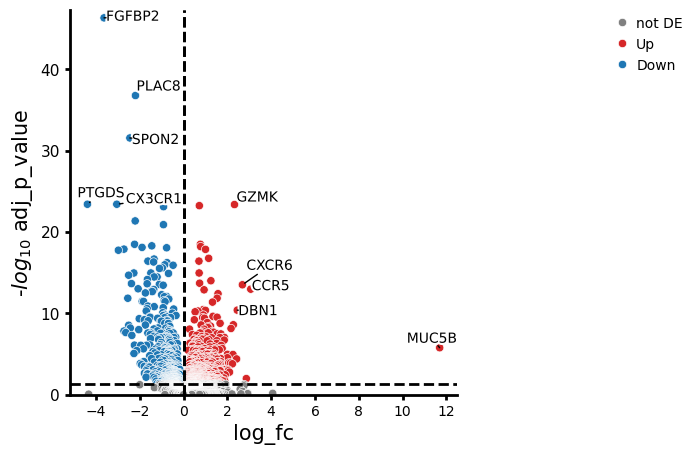

In [194]:
pds2.plot_volcano(res_df, log2fc_thresh=0)

In [195]:
filtered_res_df= res_df

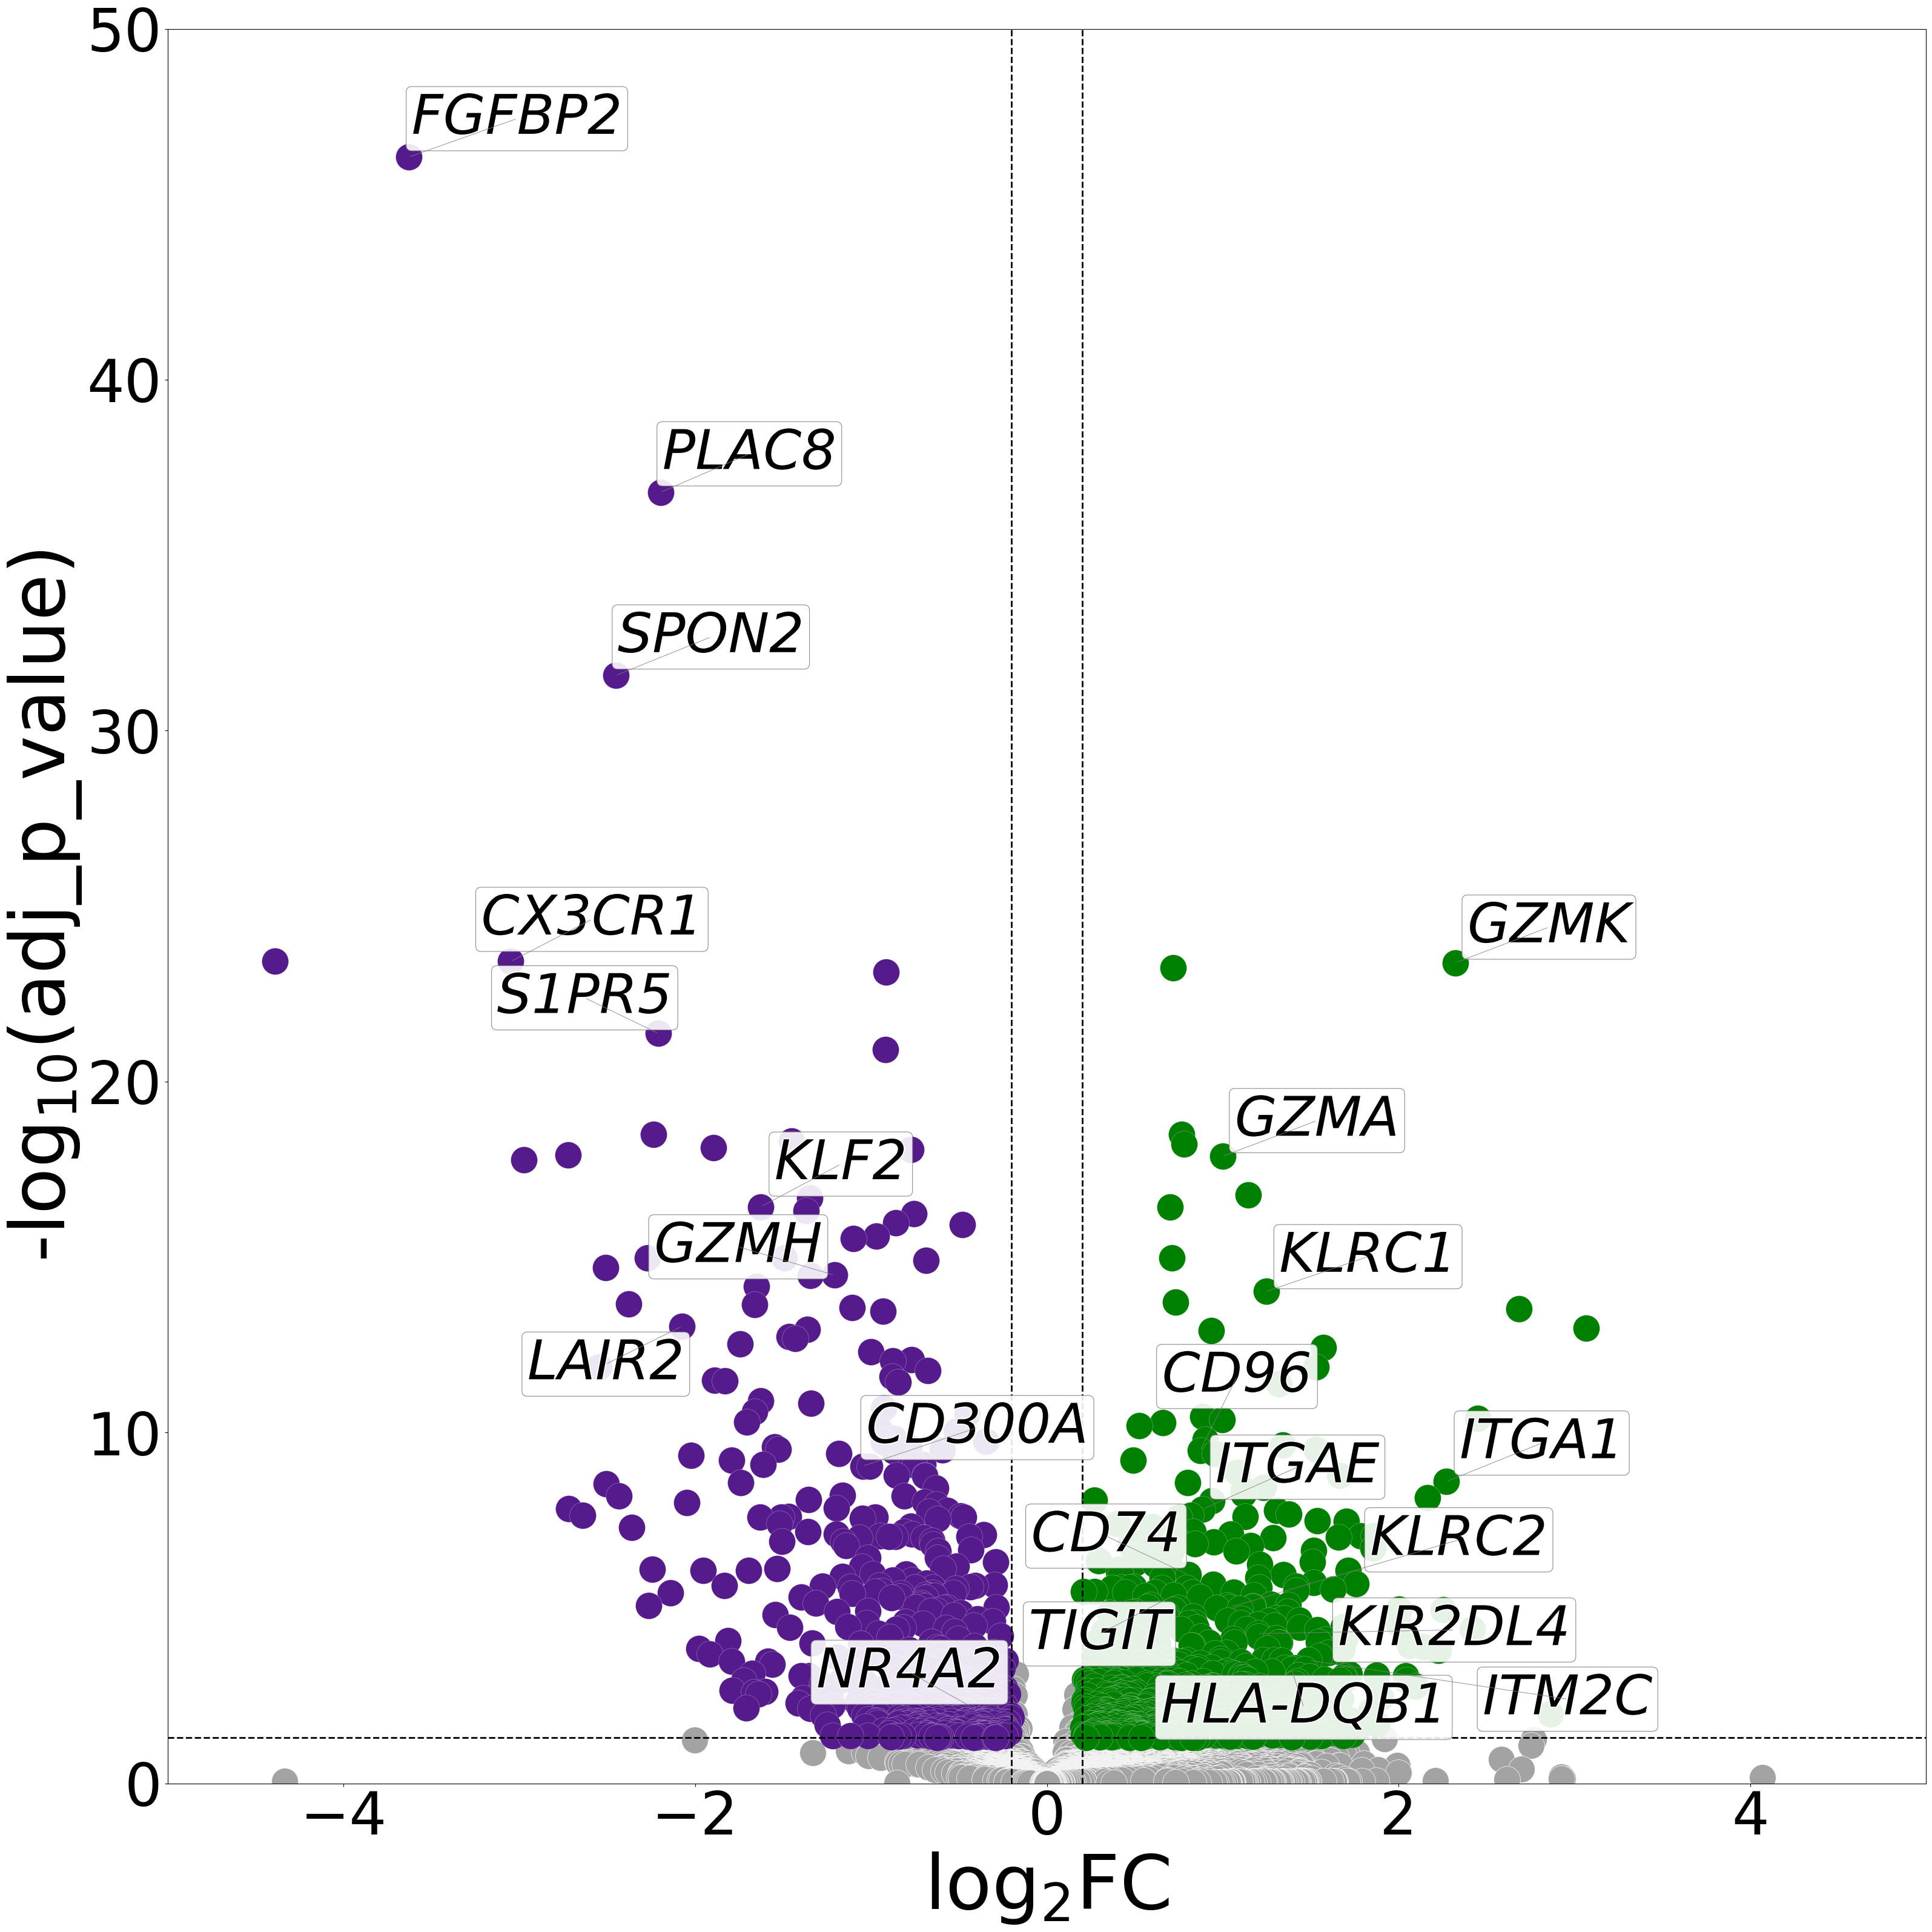

In [203]:
filtered_res_df = filtered_res_df[(filtered_res_df["log_fc"] > -15) & (filtered_res_df["log_fc"] < 8)]

# Ensure gene names are in index
filtered_res_df = filtered_res_df.set_index("variable", drop=False)
filtered_res_df["-log10(adj_p_value)"] = -np.log10(filtered_res_df["adj_p_value"])

plt.figure(figsize=(32,32))

# Significance thresholds
pval_threshold = 0.05
logfc_threshold = 0.2

# Plot all genes in light gray
plt.scatter(
    filtered_res_df["log_fc"], 
    filtered_res_df["-log10(adj_p_value)"], 
    color="#a3a3a3", s=1000, label="_nolegend_",
    edgecolors="white", linewidth=0.5
)

#  Identify significant up/down genes
sig_up = filtered_res_df[(filtered_res_df["log_fc"] > logfc_threshold) & 
                         (filtered_res_df["adj_p_value"] < pval_threshold)]
sig_down = filtered_res_df[(filtered_res_df["log_fc"] < -logfc_threshold) & 
                           (filtered_res_df["adj_p_value"] < pval_threshold)]

# Overlay significant genes
plt.scatter(
    sig_down["log_fc"], 
    sig_down["-log10(adj_p_value)"], 
    facecolors="#551A8B",       
    edgecolors="white",        # White outline
    linewidth=0.18,             # Adjust outline thickness
    s=1000, 
    label="cNK_lung_tumor"
)

plt.scatter(
    sig_up["log_fc"], 
    sig_up["-log10(adj_p_value)"], 
    facecolors="green",        # Green fill
    edgecolors="white",        # White outline
    linewidth=0.18,             # Adjust outline thickness
    s=1000, 
    label="iML_lung_tumor"
)


# Label genes of interest
genes_to_label = [
"HLA-DQB1", "KLRC1", "KIR2DL4", "KLRC2", "GZMA",
    "ITGAE", "TIGIT", "GZMK", "ITGA1", "ITM2C",
     "CD96", "CD74","S1PR5", "FGFBP2", "PLAC8", "SPON2",
    "CX3CR1", "KLF2", "LAIR2", "GZMH", "CD300A", "NR4A2"
]
texts = []
for gene in genes_to_label:
    if gene in filtered_res_df.index:
        x = filtered_res_df.loc[gene, "log_fc"]
        y = filtered_res_df.loc[gene, "-log10(adj_p_value)"]
        text = plt.text(
            x, y, gene, fontsize=65
            , color="black",
            ha='left' if x > 0 else 'right', fontstyle='italic',
            # Transparency
                    bbox=dict(
        boxstyle='round,pad=0.1',
        facecolor='white',
        edgecolor='gray',
        linewidth=0.8,
        alpha=0.9
    )    
    )
        
        # ➕ Add white outline around text
        text.set_path_effects([
            path_effects.Stroke(linewidth=2.5, foreground='white'),
            path_effects.Normal()
        ])
        texts.append(text)


# Adjust label positions
adjust_text(
    texts,
    arrowprops=dict(arrowstyle="-", color="grey", lw=0.6),
    only_move={'points':'y', 'texts':'xy'},
    force_text=2.5,
        force_points=4.5,      # Add force to move away from points
    expand_text=(1.5, 2),  # Expand text bounding boxes (x, y)
    expand_points=(1.5, 1.5)  # Expand point bounding boxes
)

# Reference line + labels
#plt.axvline(0, color="black", linestyle="--", lw=2.2)
plt.axhline(-np.log10(pval_threshold), color="black", linestyle="--",  lw=2)
plt.axvline(logfc_threshold, color="black", linestyle="--", lw=2)
plt.axvline(-logfc_threshold, color="black", linestyle="--", lw=2)
plt.ylim(0, 50)
# Make x-axis symmetric
xmax = max(abs(filtered_res_df["log_fc"].min()), abs(filtered_res_df["log_fc"].max()))
plt.xlim(-5, 5)

plt.xlabel("log$_2$FC" , fontsize=90)
plt.ylabel(r"-log$_{10}$(adj_p_value)" ,  fontsize=90)

plt.tick_params(axis='both', labelsize=70)  # Adjust size as needed
plt.tick_params(axis='both', labelsize=70)
#plt.title("Volcano Plot - Lung matched iML tumor vs cNK tumor",  fontsize=45)
#plt.legend(frameon=False, fontsize=35)
plt.tight_layout()
plt.show()
